In [2]:
import torch.nn as nn
import torch
import torch.functional as F

In [3]:
from torchvision import transforms
from torchvision.datasets import MNIST

mnist = MNIST("mnist_dataset", download=True, transform=transforms.ToTensor())

In [4]:
data_loader = torch.utils.data.DataLoader(
    mnist, 
    batch_size=4, 
    shuffle=True,
    num_workers=4
)

In [36]:
def add_noise(input: torch.Tensor):
    std = 0.4
    mean = 0
    noise = torch.randn_like(input) * std + mean
    return input + noise

In [6]:
from typing import Any


class Encoder(nn.Module):
    def __init__(self, latent_dim = 32) -> None:
        super().__init__()

        self.transformation = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),
        )
        
        self.latent = nn.Linear(
            in_features= 64 * 7 * 7, 
            out_features= latent_dim
        )
    
    def forward(self, x_batch: torch.Tensor):
        
        transformed = self.transformation(x_batch).flatten(start_dim=1)

        return self.latent(transformed)


class Decoder(nn.Module):
    def __init__(self, latent_size = 32) -> None:
        super().__init__()
        self.linear = nn.Linear(
            in_features=latent_size, 
            out_features=64*7*7
        )
        self.transformations = nn.Sequential(
             nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid(),
        )
        

    def forward(self, x):
        x = self.linear(x)
        # reshape 
        x = torch.reshape(x, (-1, 64, 7,7))
        x = self.transformations(x)
        return x
        
        
        
        
class AutoEncoder(nn.Module):
    
    
    def __init__(self, latent_size = 32) -> None:
        super().__init__()
        
        self.encoder = Encoder(latent_size)
        self.decoder = Decoder(latent_size)
        
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    

In [7]:
enc = Encoder(latent_dim=32)
out = enc(torch.randn(4, 1, 28, 28))
print(out.shape)  # should be torch.Size([4, 32])

torch.Size([4, 32])


In [8]:
dec = Decoder(latent_size=32)
z = torch.randn(4, 32)
out = dec(z)
print(out.shape)              # torch.Size([4, 1, 28, 28])
print(out.min(), out.max())   # in (0, 1)

torch.Size([4, 1, 28, 28])
tensor(0.2775, grad_fn=<MinBackward1>) tensor(0.7964, grad_fn=<MaxBackward1>)


In [9]:
auto_encoder =AutoEncoder(latent_size=32)
auto_encoder(torch.randn(4, 1, 28, 28)).shape

torch.Size([4, 1, 28, 28])

In [10]:
!uv pip install tqdm

Using Python 3.13.2 environment at: /Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv
Audited 1 package in 11ms


In [40]:
EPOCHS = 5
STEPS = 100
from tqdm import tqdm
model = AutoEncoder()
optimizer = torch.optim.Adam(
        model.parameters(), lr=1e-3
    )
loss_fn = nn.MSELoss()
for epoch in range(EPOCHS):
    print("Epoch: ", epoch)
    model.train()
    running_loss, n = 0, 0
    pbar = tqdm(data_loader, desc="Training")
    for x, target in pbar:
        x_clean = x
        x_noisy = add_noise(x)
        
        y = model(x_noisy)
        
        loss = loss_fn(y, x_clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        n += 1
        pbar.set_postfix(
            {"loss": f"{loss.item():.4f}"}
        )
        
    print("Loss after epoch: ", running_loss / n)
        
        

Epoch:  0


Training: 100%|██████████| 15000/15000 [00:50<00:00, 294.14it/s, loss=0.0093]


Loss after epoch:  0.01365885734357871
Epoch:  1


Training: 100%|██████████| 15000/15000 [00:46<00:00, 319.63it/s, loss=0.0071]


Loss after epoch:  0.010103458396795516
Epoch:  2


...

Loss after epoch:  0.009674906099401415
Epoch:  3


Training: 100%|██████████| 15000/15000 [00:47<00:00, 317.64it/s, loss=0.0092]


Loss after epoch:  0.009460985097335652
Epoch:  4


Training: 100%|██████████| 15000/15000 [00:49<00:00, 306.03it/s, loss=0.0083]

Loss after epoch:  0.009330498725463016


In [41]:
data_iter = iter(data_loader)
inputs, labels = next(data_iter)

In [42]:
inputs.shape

torch.Size([4, 1, 28, 28])

In [43]:
x_clean = inputs
x_noisy = add_noise(inputs)
with torch.inference_mode():
    output = model.forward(
        x_noisy
    )
output.shape, x_noisy.shape

(torch.Size([4, 1, 28, 28]), torch.Size([4, 1, 28, 28]))

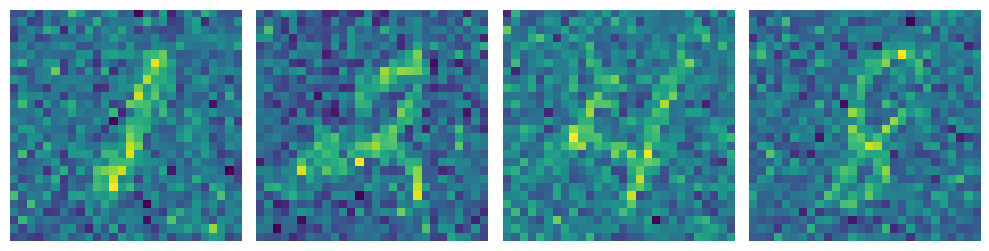

In [44]:
import matplotlib.pyplot as plt

# Visualize the first four images in the batch
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i in range(4):
    img = x_noisy[i].cpu()
    img_numpy = img.permute(1, 2, 0).squeeze().numpy()
    axes[i].imshow(img_numpy)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


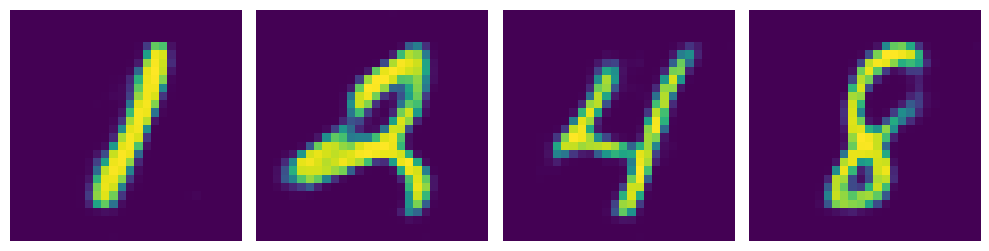

In [45]:
import matplotlib.pyplot as plt

# Visualize the first four images in the batch
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i in range(4):
    img = output[i].cpu()
    img_numpy = img.permute(1, 2, 0).squeeze().numpy()
    axes[i].imshow(img_numpy)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


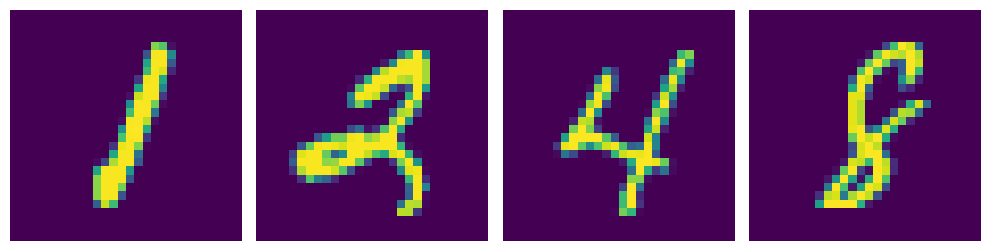

In [46]:
import matplotlib.pyplot as plt

# Visualize the first four images in the batch
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i in range(4):
    img = x_clean[i].cpu()
    img_numpy = img.permute(1, 2, 0).squeeze().numpy()
    axes[i].imshow(img_numpy)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
